# Data Validation & Cleaning
## Detect Corrupted Images and Validate Formats

This notebook identifies:
- Corrupted or unreadable images
- Format inconsistencies
- Missing or zero-size files
- Image dimension variations

In [14]:
import json
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import logging
import warnings
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import json
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter
import os

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Define Validation Functions

In [11]:
def validate_image(image_path):
    """
    Validate a single image for integrity and format.
    Returns: (is_valid, error_type, width, height, format)
    """
    try:
        if not image_path.exists():
            return False, 'FILE_NOT_FOUND', None, None, None
        
        if image_path.stat().st_size == 0:
            return False, 'ZERO_SIZE', None, None, None
        
        with Image.open(image_path) as img:
            img.load()
            width, height = img.size
            format_type = img.format
            return True, None, width, height, format_type
    
    except Image.UnidentifiedImageError:
        return False, 'UNIDENTIFIED_FORMAT', None, None, None
    except (IOError, OSError):
        return False, 'CORRUPTED_FILE', None, None, None
    except Exception as e:
        return False, f'UNKNOWN_ERROR: {type(e).__name__}', None, None, None

logger.info('Validation functions defined')

INFO:__main__:Validation functions defined


## 2. Load Metadata and Scan Dataset

In [16]:
metadata_path = Path('../dataset/dataset_metadata.json')
dataset_root = Path('../dataset')

with open(metadata_path, 'r') as f:
    metadata = json.load(f)

class_names = metadata['class_names']
total_expected = metadata['total_images']

logger.info(f'Loading validation for {len(class_names)} classes')
logger.info(f'Expected total images: {total_expected:,}')

INFO:__main__:Loading validation for 53 classes
INFO:__main__:Expected total images: 213,522


### Scan and validate data

In [ ]:


# ── Constants ────────────────────────────────────────────────────────────────
VALID_EXTENSIONS = frozenset({'.jpg', '.jpeg', '.png'})
SPLITS = ('train', 'val', 'test')

# ── Validation function ───────────────────────────────────────────────────────
def quick_validate_image(args: tuple) -> dict:
    """Validate a single image. Returns a result dict directly (avoids tuple unpacking overhead)."""
    class_name, image_path = args
    base = {'Image_Path': str(image_path), 'Class': class_name,
            'Valid': False, 'Error': None, 'Width': None, 'Height': None, 'Format': None}
    try:
        stat = image_path.stat()
        if stat.st_size == 0:
            return {**base, 'Error': 'ZERO_SIZE'}
        with Image.open(image_path) as img:
            img.load()
            return {**base, 'Valid': True, 'Width': img.width,
                    'Height': img.height, 'Format': img.format}
    except FileNotFoundError:
        return {**base, 'Error': 'FILE_NOT_FOUND'}
    except Image.UnidentifiedImageError:
        return {**base, 'Error': 'UNIDENTIFIED_FORMAT'}
    except (IOError, OSError):
        return {**base, 'Error': 'CORRUPTED_FILE'}
    except Exception as e:
        return {**base, 'Error': f'UNKNOWN_ERROR: {type(e).__name__}'}

# ── Bootstrap: paths & metadata ──────────────────────────────────────────────
if 'metadata_path' not in dir():
    metadata_path = Path('../dataset/dataset_metadata.json')
    dataset_root  = Path('../dataset')

if 'class_names' not in dir():
    with open(metadata_path) as f:
        class_names = json.load(f)['class_names']

# ── Collect candidates (generator → no intermediate list until needed) ────────
def iter_candidates(dataset_root, splits, class_names, valid_extensions):
    for split in splits:
        for class_name in class_names:
            class_path = dataset_root / split / class_name
            if not class_path.is_dir():
                if 'logger' in dir(): logger.warning(f'Missing: {class_path}')
                continue
            for item in class_path.iterdir():
                if item.is_file() and item.suffix.lower() in valid_extensions:
                    yield class_name, item

image_candidates = list(iter_candidates(dataset_root, SPLITS, class_names, VALID_EXTENSIONS))

if 'logger' in dir():
    logger.info(f'Found {len(image_candidates):,} image files to validate')

# ── Parallel validation ───────────────────────────────────────────────────────
MAX_WORKERS = min(32, (os.cpu_count() or 4) * 2)  # I/O-bound: use more threads

validation_results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(quick_validate_image, args): args for args in image_candidates}
    for future in tqdm(as_completed(futures), total=len(image_candidates), desc='Validating images'):
        validation_results.append(future.result())

# ── Aggregate in one pass ─────────────────────────────────────────────────────
format_counts    = Counter()
image_dimensions = []

for r in validation_results:
    if r['Valid']:
        format_counts[r['Format']] += 1
        if r['Width']:
            image_dimensions.append((r['Width'], r['Height']))

df_validation = pd.DataFrame(validation_results)

if 'logger' in dir():
    total   = len(df_validation)
    valid   = df_validation['Valid'].sum()
    invalid = total - valid
    logger.info(f'Validation complete — {valid:,} valid / {invalid:,} invalid / {total:,} total')

Validating images: 100%|██████████| 213519/213519 [07:03<00:00, 503.64it/s] 


## 4. Validation Report

In [13]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter
import os
import logging

# ── Logger ────────────────────────────────────────────────────────────────────
if 'logger' not in dir():
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s | %(levelname)s | %(message)s',
        datefmt='%H:%M:%S'
    )
    logger = logging.getLogger(__name__)

# ── Validation function ───────────────────────────────────────────────────────
def validate_image(image_path):
    try:
        if not image_path.exists():
            return False, 'FILE_NOT_FOUND', None, None, None
        if image_path.stat().st_size == 0:
            return False, 'ZERO_SIZE', None, None, None
        with Image.open(image_path) as img:
            img.load()
            return True, None, img.width, img.height, img.format
    except Image.UnidentifiedImageError:
        return False, 'UNIDENTIFIED_FORMAT', None, None, None
    except (IOError, OSError):
        return False, 'CORRUPTED_FILE', None, None, None
    except Exception as e:
        return False, f'UNKNOWN_ERROR: {type(e).__name__}', None, None, None

# ── rest of the cell unchanged below ─────────────────────────────────────────
VALID_EXTENSIONS = frozenset({'.jpg', '.jpeg', '.png'})
SPLITS = ('train', 'val', 'test')

def iter_candidates(dataset_root, splits, class_names, valid_extensions):
    for split in splits:
        for class_name in class_names:
            class_path = dataset_root / split / class_name
            if not class_path.is_dir():
                logger.warning(f'Class directory not found: {class_path}')
                continue
            for item in class_path.iterdir():
                if item.is_file() and item.suffix.lower() in valid_extensions:
                    yield class_name, item

image_candidates = list(iter_candidates(dataset_root, SPLITS, class_names, VALID_EXTENSIONS))
logger.info(f'Found {len(image_candidates):,} image files to validate')

MAX_WORKERS = min(32, (os.cpu_count() or 4) * 2)
validation_results = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(validate_image, path): (cls, path)
               for cls, path in image_candidates}
    for future in tqdm(as_completed(futures), total=len(image_candidates), desc='Validating'):
        cls, path = futures[future]
        is_valid, error_type, width, height, format_type = future.result()
        validation_results.append({
            'Image_Path'  : str(path),
            'Class'       : cls,
            'Valid'       : is_valid,
            'Error'       : error_type,
            'Width'       : width,
            'Height'      : height,
            'Format'      : format_type,
        })

format_counts    = Counter()
image_dimensions = []
for r in validation_results:
    if r['Valid']:
        format_counts[r['Format']] += 1
        if r['Width']:
            image_dimensions.append((r['Width'], r['Height']))

df_validation    = pd.DataFrame(validation_results)
total_images     = len(df_validation)
valid_images     = int(df_validation['Valid'].sum())
corrupted_images = total_images - valid_images

SEP  = "=" * 60
DASH = "-" * 60
pct  = lambda n: f"{n / total_images * 100:.2f}%" if total_images else "N/A"

print(f"\n{SEP}")
print("DATA VALIDATION REPORT")
print(SEP)
print(f"\n  Total Scanned  : {total_images:,}")
print(f"  Valid          : {valid_images:,}  ({pct(valid_images)})")
print(f"  Corrupted      : {corrupted_images:,}  ({pct(corrupted_images)})")

if 'total_expected' in dir():
    diff = total_expected - total_images
    sign = '+' if diff >= 0 else ''
    print(f"\n  Expected       : {total_expected:,}")
    print(f"  Difference     : {sign}{diff:,}")

if corrupted_images > 0:
    print(f"\n{DASH}\nERROR BREAKDOWN\n{DASH}")
    for err, cnt in df_validation[~df_validation['Valid']]['Error'].value_counts().items():
        print(f"  {err:<35} {cnt:,}")
    print(f"\n{DASH}\nCORRUPTED BY CLASS\n{DASH}")
    for cls, cnt in df_validation[~df_validation['Valid']].groupby('Class').size().items():
        print(f"  {cls:<35} {cnt:,}")
else:
    print("\n  ✓ No corrupted images detected!")

print(SEP)

15:14:11 | INFO | Found 213,519 image files to validate
Validating: 100%|██████████| 213519/213519 [09:36<00:00, 370.06it/s] 



DATA VALIDATION REPORT

  Total Scanned  : 213,519
  Valid          : 213,519  (100.00%)
  Corrupted      : 0  (0.00%)

  ✓ No corrupted images detected!


## 5. Image Format Analysis

In [ ]:
print("\n" + "="*60)
print("IMAGE FORMAT DISTRIBUTION")
print("="*60)
for fmt, count in sorted(format_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / sum(format_counts.values())) * 100
    print(f"{fmt}: {count:,} ({percentage:.1f}%)")


IMAGE FORMAT DISTRIBUTION
JPEG: 436,397 (100.0%)
PNG: 1 (0.0%)


## 6. Image Dimension Analysis

In [ ]:
if image_dimensions:
    widths = [d[0] for d in image_dimensions]
    heights = [d[1] for d in image_dimensions]
    
    print("\n" + "="*60)
    print("IMAGE DIMENSION STATISTICS")
    print("="*60)
    print(f"\nWidth (pixels):")
    print(f"  Min: {np.min(widths)}")
    print(f"  Max: {np.max(widths)}")
    print(f"  Mean: {np.mean(widths):.1f}")
    print(f"  Median: {np.median(widths):.1f}")
    
    print(f"\nHeight (pixels):")
    print(f"  Min: {np.min(heights)}")
    print(f"  Max: {np.max(heights)}")
    print(f"  Mean: {np.mean(heights):.1f}")
    print(f"  Median: {np.median(heights):.1f}")
    
    # Aspect ratios
    aspect_ratios = [w/h for w, h in image_dimensions]
    print(f"\nAspect Ratios:")
    print(f"  Min: {np.min(aspect_ratios):.3f}")
    print(f"  Max: {np.max(aspect_ratios):.3f}")
    print(f"  Mean: {np.mean(aspect_ratios):.3f}")
    print(f"  Median: {np.median(aspect_ratios):.3f}")


IMAGE DIMENSION STATISTICS

Width (pixels):
  Min: 93
  Max: 400
  Mean: 341.8
  Median: 400.0

Height (pixels):
  Min: 107
  Max: 400
  Mean: 341.8
  Median: 400.0

Aspect Ratios:
  Min: 0.574
  Max: 1.500
  Mean: 1.000
  Median: 1.000


## 7. Visualization of Dimensions

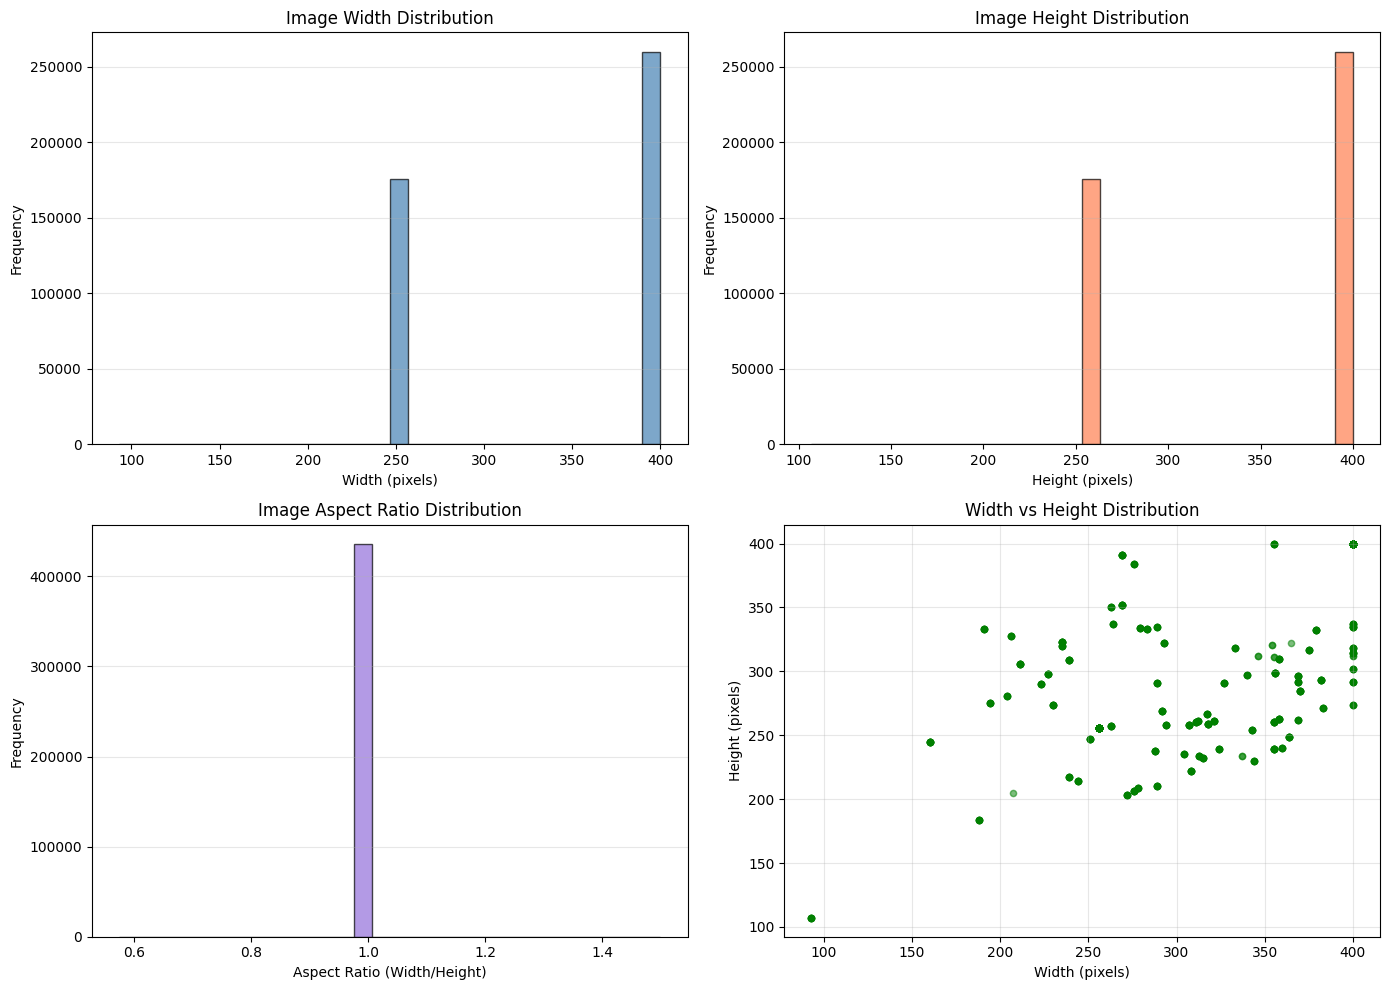

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if image_dimensions:
    # Width distribution
    ax = axes[0, 0]
    ax.hist(widths, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Width (pixels)')
    ax.set_ylabel('Frequency')
    ax.set_title('Image Width Distribution')
    ax.grid(axis='y', alpha=0.3)
    
    # Height distribution
    ax = axes[0, 1]
    ax.hist(heights, bins=30, color='coral', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Height (pixels)')
    ax.set_ylabel('Frequency')
    ax.set_title('Image Height Distribution')
    ax.grid(axis='y', alpha=0.3)
    
    # Aspect ratio distribution
    ax = axes[1, 0]
    ax.hist(aspect_ratios, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Aspect Ratio (Width/Height)')
    ax.set_ylabel('Frequency')
    ax.set_title('Image Aspect Ratio Distribution')
    ax.grid(axis='y', alpha=0.3)
    
    # Width vs Height scatter
    ax = axes[1, 1]
    ax.scatter(widths, heights, alpha=0.3, s=20, color='green')
    ax.set_xlabel('Width (pixels)')
    ax.set_ylabel('Height (pixels)')
    ax.set_title('Width vs Height Distribution')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/03_image_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Data Quality Summary

In [ ]:
print("\n" + "="*60)
print("DATA QUALITY SUMMARY")
print("="*60)
print(f"\n✓ Dataset Status: {'CLEAN' if corrupted_images == 0 else 'REQUIRES CLEANING'}")
print(f"✓ Format Consistency: {'OK' if len(format_counts) <= 2 else 'MIXED'}")
print(f"✓ Dimension Consistency: {'OK' if np.std(widths) < 50 else 'HIGH VARIATION'}")
print(f"\nRecommendations:")
if corrupted_images > 0:
    print(f"  - Remove {corrupted_images} corrupted images before training")
if np.std(widths) > 50:
    print(f"  - Standardize image sizes (current std: {np.std(widths):.1f} px)")
print(f"  - Consider resizing to standard format (e.g., 224x224, 256x256)")


DATA QUALITY SUMMARY

✓ Dataset Status: REQUIRES CLEANING
✓ Format Consistency: OK
✓ Dimension Consistency: HIGH VARIATION

Recommendations:
  - Remove 9369 corrupted images before training
  - Standardize image sizes (current std: 70.7 px)
  - Consider resizing to standard format (e.g., 224x224, 256x256)
